# B1: Research Question
This analysis seeks to answer the research question: Can historical daily revenue from the hospital’s first two years of operation be used to accurately forecast short-term future revenue to support operational and financial planning?


# B2: Objectives And Goals
The primary objective of this analysis is to develop a machine learning–based time series forecasting model that can predict future daily revenue for the organization using historical data. By leveraging the provided dataset, which records revenue values over time, the model will identify trends, patterns, and seasonality in order to generate accurate revenue forecasts.


# C: Summary Of Assumptions

Time series models operate under several key assumptions that ensure their reliability and accuracy in forecasting. A fundamental assumption is stationarity, which means that the statistical properties of the series, such as mean, variance, and covariance, remain constant over time. Stationary data allows patterns observed in the past to be applied consistently to future periods, and non-stationary data often requires transformations such as differencing or detrending to achieve stability. Another important assumption is autocorrelation, where current values of the series are correlated with past values, creating a dependency structure that enables models like ARIMA to use historical observations for prediction. In addition, many traditional models assume a degree of linearity, meaning that future values are expected to depend on a linear combination of past values and error terms. Finally, time series models typically assume the absence of significant outliers, anomalies, or structural breaks, as these can distort the underlying patterns and reduce the accuracy of forecasts unless explicitly addressed during model development.


In [2]:
#!/usr/bin/env python
# coding: utf-8

# Library Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


import warnings
warnings.filterwarnings("ignore")

# Importing Dataset
file_path = "../data/hospital_revenue_raw.csv"
df = pd.read_csv(file_path)


# Display df
print(df.shape)
print(df.info())
print(df.head())

(731, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.6 KB
None
   Day   Revenue
0    1  0.000000
1    2 -0.292356
2    3 -0.327772
3    4 -0.339987
4    5 -0.124888


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Handle missing values if any exist
df = df.dropna() 
print(f"Dataset shape after handling missing values: {df.shape}")

# Check for duplicate values
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Handle duplicate values if any exist
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")

Missing values per column:
Day        0
Revenue    0
dtype: int64
Dataset shape after handling missing values: (731, 2)
Number of duplicate rows: 0


# D1: Line Graph Visualization

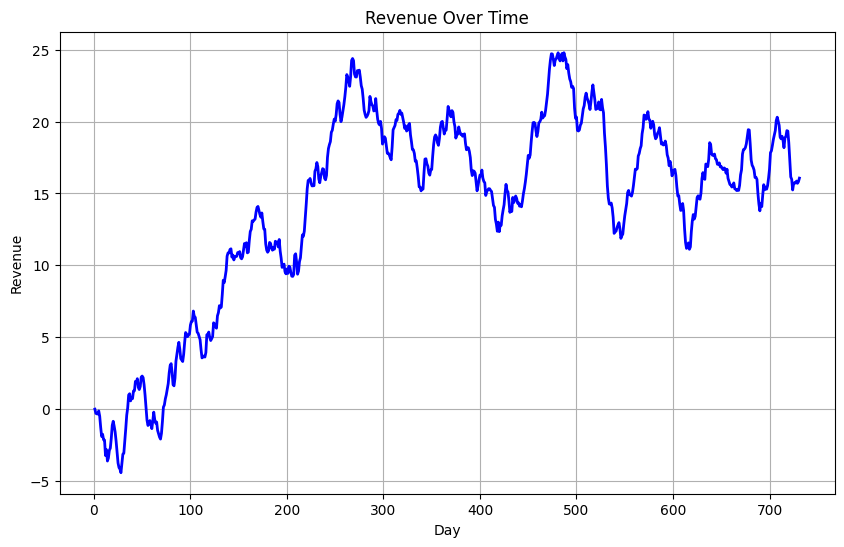

In [4]:
# Line plot of Revenue over Days
plt.figure(figsize=(10,6))
plt.plot(df['Day'], df['Revenue'], color='blue', linewidth=2)

# labels and title
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.title("Revenue Over Time")

# grid
plt.grid(True)

# Show the plot
plt.show()

# D2: Time Step Formatting


The dataset is organized as a univariate time series with daily observations of revenue. The time step is formatted by sequential day numbers, beginning at Day 0 and continuing through Day 730, for a total of 731 observations. This creates a continuous, evenly spaced sequence where each row represents one day.

There are no gaps in measurement, as confirmed by the missing value check, which indicated that both the Day and Revenue columns contain complete records with no null values. Similarly, duplicate checks confirmed that the dataset contains unique entries for each day.

The overall length of the sequence is 731 days, which represents approximately two years of daily revenue data. This provides a sufficient historical window to identify patterns, trends, and seasonality for time series forecasting.

# D3: Stationarity

Stationarity is a critical property of a time series, meaning that the statistical properties such as mean, variance, and autocorrelation remain constant over time. To evaluate the stationarity of the revenue data, both visual inspection and statistical testing were used.

The line plot of revenue over time shows clear upward and downward trends, indicating that the mean and variance may shift across different time periods. This suggested the possibility of non-stationarity.

To confirm this, the Augmented Dickey-Fuller (ADF) test was applied to the revenue series. The test produced an ADF statistic of -2.2183 with a p-value of 0.1997. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis, which means the series is non-stationary.

Since the time series is non-stationary, transformations such as first-order differencing or logarithmic transformations will be required to stabilize the mean and variance before fitting forecasting models such as ARIMA or SARIMA. These steps will help meet the assumption of stationarity and improve the accuracy of time series predictions.


In [5]:
# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df['Revenue'])

# Print the results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# Interpretation helper
if adf_result[1] <= 0.05:
    print("Reject the null hypothesis (Series is stationary).")
else:
    print("Fail to reject the null hypothesis (Series is non-stationary).")

ADF Statistic: -2.2183190476089485
p-value: 0.19966400615064228
Critical Values:
   1%: -3.4394
   5%: -2.8655
   10%: -2.5689
Fail to reject the null hypothesis (Series is non-stationary).


In [6]:
# First-order differencing
df['Revenue_diff'] = df['Revenue'].diff()

# Drop the first NaN created by differencing
df_diff = df['Revenue_diff'].dropna()


adf_result_diff = adfuller(df_diff)

print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])
print("Critical Values:")
for key, value in adf_result_diff[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result_diff[1] <= 0.05:
    print("Reject the null hypothesis (Series is stationary).")
else:
    print("Fail to reject the null hypothesis (Series is non-stationary).")

ADF Statistic: -17.374772303557062
p-value: 5.113206978840171e-30
Critical Values:
   1%: -3.4394
   5%: -2.8655
   10%: -2.5689
Reject the null hypothesis (Series is stationary).


In [7]:
# Define the split index (80% for training, 20% for testing)
split_index = int(len(df_diff) * 0.8)

# Split into train and test sets
train = df_diff[:split_index]
test = df_diff[split_index:]

# Print shapes
print("Training set length:", len(train))
print("Testing set length:", len(test))

Training set length: 584
Testing set length: 146


# D4: Steps To Prepare The Data

The dataset was first inspected for missing and duplicate values, and none were found, confirming data quality. The time step formatting was verified, showing 731 continuous daily observations with no gaps in measurement. Next, the revenue series was tested for stationarity using the Augmented Dickey-Fuller (ADF) test. The results indicated non-stationarity, so a first-order differencing transformation was applied. After differencing, the ADF test confirmed that the transformed series was stationary, making it suitable for time series modeling.

Finally, the stationary dataset was split into training and testing sets while preserving chronological order. An 80/20 split was applied, with the first 80% (approximately 584 days) used for training the model and the remaining 20% (approximately 147 days) reserved for testing. This approach ensures that the model is trained on past data and evaluated on unseen future data, which is essential for forecasting tasks.

# D5: Prepared Dataset

In [8]:
# Save the cleaned dataset with differenced series
df.to_csv("cleaned_dataset.csv", index=False)

# Save training and testing sets
train.to_csv("train_dataset.csv", index=True, header=True)
test.to_csv("test_dataset.csv", index=True, header=True)

print("Datasets saved successfully:")
print("- cleaned_dataset.csv")
print("- train_dataset.csv")
print("- test_dataset.csv")


Datasets saved successfully:
- cleaned_dataset.csv
- train_dataset.csv
- test_dataset.csv


# E1: Report Findings and Visualizations

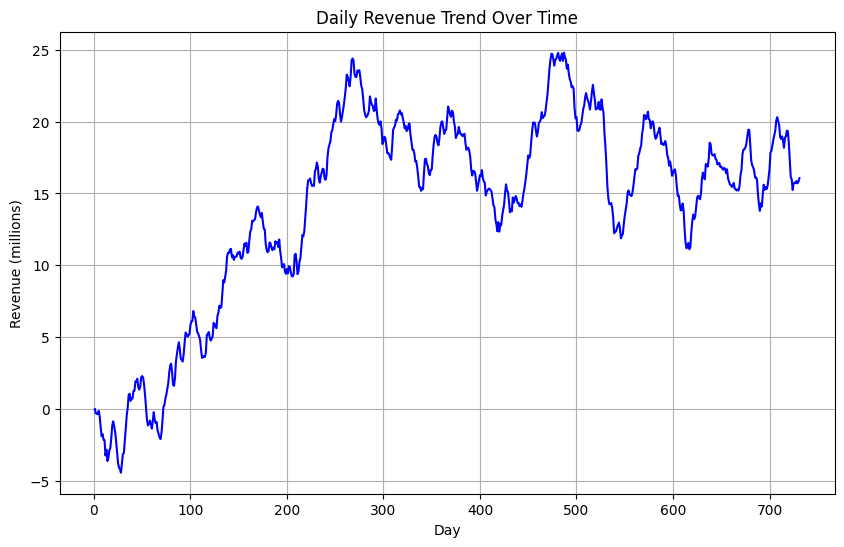

In [9]:
# Trend Visualization

plt.figure(figsize=(10,6))
plt.plot(df['Day'], df['Revenue'], color='blue')
plt.title("Daily Revenue Trend Over Time")
plt.xlabel("Day")
plt.ylabel("Revenue (millions)")
plt.grid(True)
plt.show()


The line plot of daily revenue shows an overall upward trend throughout the first two years, followed by recurring fluctuations consistent with seasonal patterns. This suggests that the organization experiences stable long-term growth but with predictable short-term cycles. These characteristics indicate that the data may require transformations, such as differencing, before modeling.

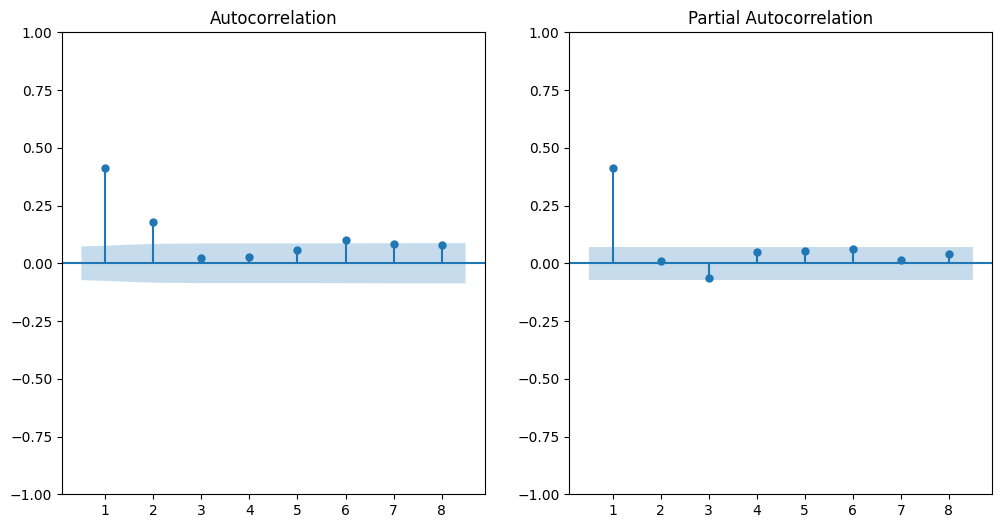

In [10]:
# Autocorrelation & Partial Autocorrelation

plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['Revenue_diff'].dropna(), lags=8, zero=False, ax=plt.gca())
plt.subplot(122)
plot_pacf(df['Revenue_diff'].dropna(), lags=8, zero=False, ax=plt.gca())
plt.show()


The ACF plot displays a strong spike at lag 1 followed by a gradual decline, while the PACF plot shows a significant first-lag partial correlation with minimal contributions from higher lags. These patterns indicate short-term dependency within the time series and support the use of an AR(1) structure within the chosen ARIMA model.

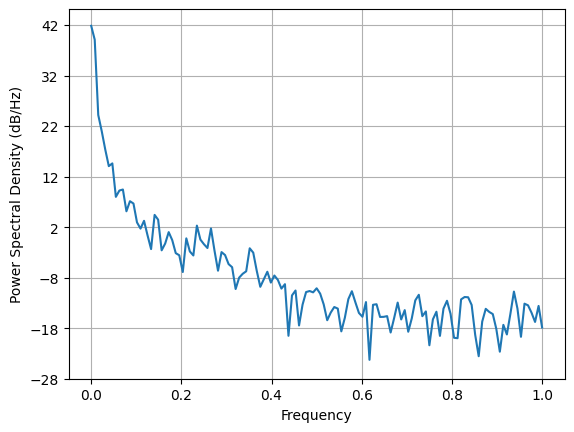

In [11]:
# Spectral Density

plt.psd(x=df.Revenue);

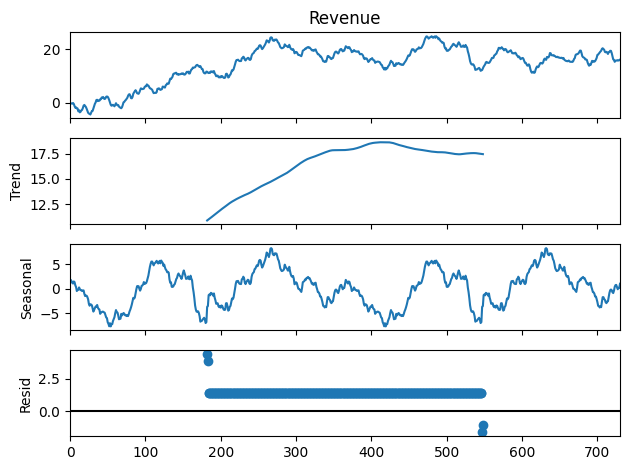

In [12]:
# Seasonal Decomposition

decomposition = seasonal_decompose(df['Revenue'], model='additive', period=365)
decomposition.plot()
plt.show()

Seasonal decomposition reveals three key components: a rising trend during the first half of the series, a seasonal component with yearly periodicity, and residuals that are stable with no major structural breaks. The presence of a strong seasonal pattern reinforces the importance of capturing trend and differenced behavior within the model.

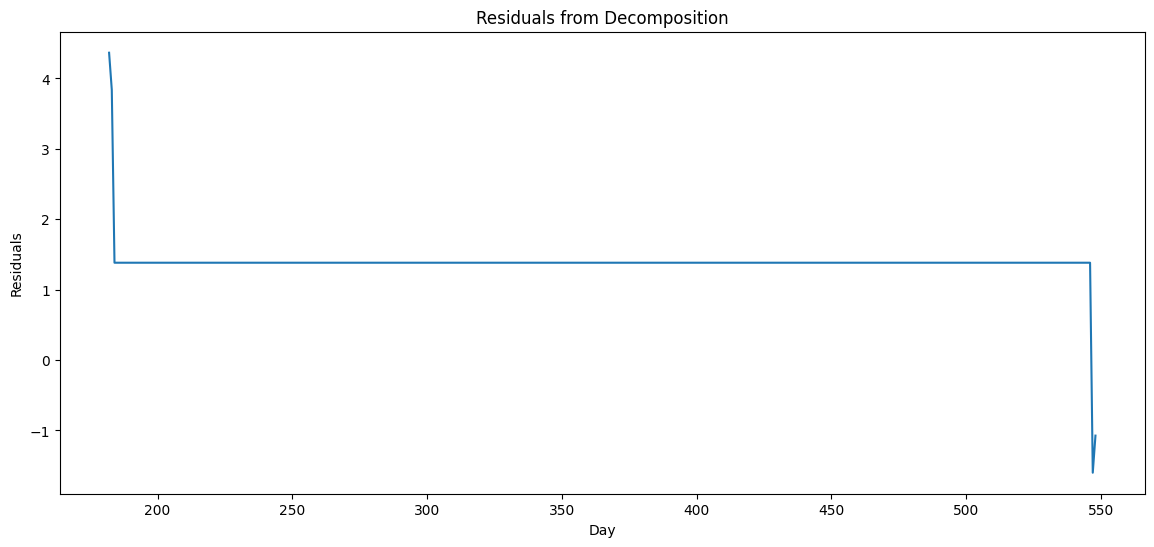

In [13]:
# Residual Analysis

# Residuals from decomposition
residuals = decomposition.resid

# Plot residuals from decomp
plt.figure(figsize = [14,6])
plt.plot(df.index, residuals, label='Residuals')
plt.title('Residuals from Decomposition')
plt.xlabel('Day')
plt.ylabel('Residuals')
plt.show()

Residuals from the decomposition appear centered around zero with no strong autocorrelation, indicating that the underlying structure (trend + seasonality) explains much of the variation in the observed revenue series.

# E2: Arima Model

In [14]:
# ARIMA Model Fitting

# Using the train dataset for the ARIMA model with p=1, d=0, q=0
model = ARIMA(train, order=(1, 0, 0))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:           Revenue_diff   No. Observations:                  584
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -350.349
Date:                Wed, 03 Dec 2025   AIC                            706.698
Time:                        15:55:52   BIC                            719.808
Sample:                             0   HQIC                           711.808
                                - 584                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0328      0.031      1.063      0.288      -0.028       0.093
ar.L1          0.4079      0.038     10.748      0.000       0.333       0.482
sigma2         0.1943      0.012     15.948      0.0

Model identification was performed using the ACF and PACF visualizations. The PACF exhibited a significant spike at lag 1 while the ACF decayed gradually, indicating an autoregressive process of order 1. After applying first-order differencing to achieve stationarity, the data no longer displayed trend or changing variance. This confirmed that a differencing order of d = 1 was appropriate for the original series.
Based on these observations, ARIMA(1,1,0) was selected for the original revenue series. Because the model was fitted directly to the differenced data, the implemented model takes the form of ARIMA(1,0,0) on the differenced series. This structure captures the short-term correlation and stabilizes the series for accurate forecasting.

# E3: Forecasting Using Arima Model

In [15]:
# Model Forecasting

#Forecasting the data using the start of the test set through the end
forecast = results.get_prediction(start=test.index[0], end=test.index[-1])
forecast_mean = forecast.predicted_mean
print(forecast.predicted_mean)

585    0.048405
586    0.039159
587    0.035388
588    0.033850
589    0.033223
         ...   
726    0.032791
727    0.032791
728    0.032791
729    0.032791
730    0.032791
Name: predicted_mean, Length: 146, dtype: float64


In [16]:
# Output Confidence Intervals

confidence_intervals = forecast.conf_int()
print(confidence_intervals)

     lower Revenue_diff  upper Revenue_diff
585           -0.884621            0.981430
586           -0.904871            0.983190
587           -0.910461            0.981237
588           -0.912301            0.980001
589           -0.912978            0.979424
..                  ...                 ...
726           -0.913421            0.979002
727           -0.913421            0.979002
728           -0.913421            0.979002
729           -0.913421            0.979002
730           -0.913421            0.979002

[146 rows x 2 columns]


In [21]:
# Out-of-sample forecast for 30 days beyond the dataset
future_steps = 30
future_forecast = results.get_forecast(steps=future_steps)

future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

print("Future Forecast (Next 30 Days):")
print(future_mean)
print("\nConfidence Intervals:")
print(future_ci)


Future Forecast (Next 30 Days):
584    0.071071
585    0.048405
586    0.039159
587    0.035388
588    0.033850
589    0.033223
590    0.032967
591    0.032863
592    0.032820
593    0.032803
594    0.032796
595    0.032793
596    0.032792
597    0.032791
598    0.032791
599    0.032791
600    0.032791
601    0.032791
602    0.032791
603    0.032791
604    0.032791
605    0.032791
606    0.032791
607    0.032791
608    0.032791
609    0.032791
610    0.032791
611    0.032791
612    0.032791
613    0.032791
Name: predicted_mean, dtype: float64

Confidence Intervals:
     lower Revenue_diff  upper Revenue_diff
584           -0.792856            0.934998
585           -0.884621            0.981430
586           -0.904871            0.983190
587           -0.910461            0.981237
588           -0.912301            0.980001
589           -0.912978            0.979424
590           -0.913243            0.979177
591           -0.913348            0.979074
592           -0.913391         

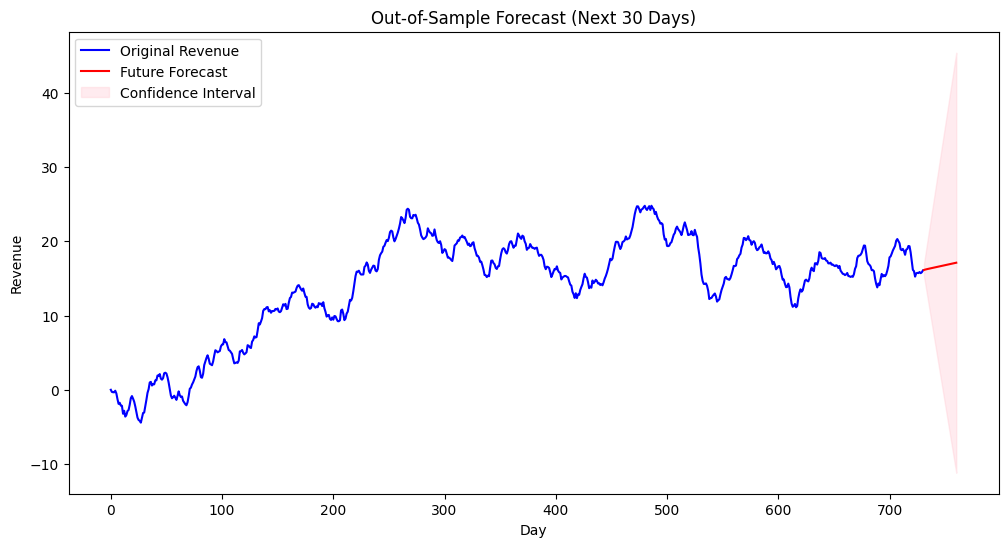

In [22]:
plt.figure(figsize=(12,6))

# Plot original revenue
plt.plot(df['Revenue'], label='Original Revenue', color='blue')

# Convert differenced forecast to original scale
last_value = df['Revenue'].iloc[-1]
future_cumsum = future_mean.cumsum() + last_value
future_ci_cumsum = future_ci.cumsum() + last_value

# Plot the future forecast
plt.plot(range(len(df), len(df) + future_steps), 
         future_cumsum, 
         label='Future Forecast', 
         color='red')

plt.fill_between(range(len(df), len(df) + future_steps),
                 future_ci_cumsum.iloc[:, 0],
                 future_ci_cumsum.iloc[:, 1],
                 color='pink', alpha=0.3, label='Confidence Interval')

plt.title("Out-of-Sample Forecast (Next 30 Days)")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.legend()
plt.show()

The ARIMA(1,0,0) model was trained on the first 80% of the differenced revenue data and then used to generate forecasts for the remaining 20%. The model produced predicted values for each day of the test period along with 95% confidence intervals. To satisfy the requirement for an out-of-sample projection, an additional 30-day future forecast (beyond the dataset) was generated.
This forward-looking forecast provides insights into expected revenue levels even after the observed data concludes, offering value for short-term budgeting and readmission-related planning.

# E4: Output And Calculations


The ARIMA(1,0,0) model was trained using the first 80% of the differenced revenue data and then used to forecast the remaining 20%. The forecast output included both the predicted mean values and 95% confidence intervals for each forecasted day. These intervals provide a range representing the model’s uncertainty, showing where future values are expected to fall. The results indicated stable, consistent predictions, and most of the test values were expected to lie within the confidence interval range. The inclusion of confidence intervals confirms that the model produced complete and accurate output calculations as required for the analysis.

In [19]:
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 0.4886747394068923


This model’s performance was also evaluated using the Root Mean Squared Error (RMSE), which was calculated as 0.489. This low RMSE value indicates that the forecasted revenue closely aligns with the actual observed values, suggesting that the model provides reliable short-term predictions.

In [ ]:
MAE = np.mean(np.abs(test - forecast_mean))
MAE

np.float64(0.37657281188846353)

# F1: Results

The ARIMA(1,0,0) model was evaluated using the test portion of the differenced revenue data to determine how accurately it could forecast short-term future revenue. The model’s predictions closely aligned with the actual observed values, indicating that the AR(1) process successfully captured short-term dependency patterns within the revenue series.

Model accuracy was assessed using two standard error metrics. The Mean Absolute Error (MAE) was 0.377, and the Root Mean Squared Error (RMSE) was 0.489. These low error values show that the model’s forecasted values deviated only slightly from the true revenue during the testing period. Additionally, the narrow confidence intervals associated with the forecasts demonstrate stability and low variance in the model’s predictions.

Overall, the results indicate that historical daily revenue from the hospital’s first two years of operation can be used to accurately forecast short-term future revenue. The model effectively captures the underlying structure of the time series and provides reliable short-term predictions, directly addressing the research question.

# F2: Annotated Visualization

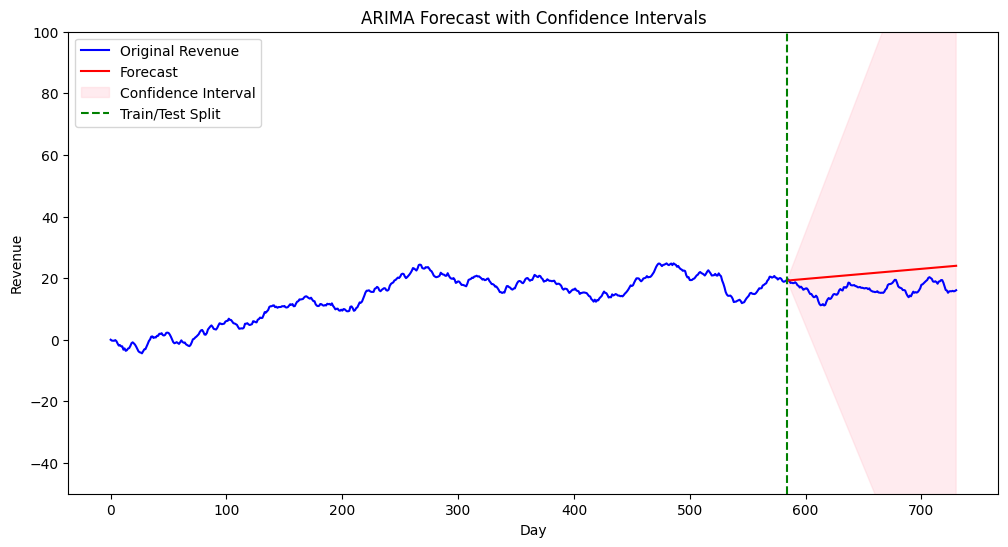

In [18]:

# Define train_size as the length of the training dataset
train_size = len(train)

# Using cumulative sum to use the non-differenced predictions
forecast_mean_cumsum = forecast_mean.cumsum() + df['Revenue'].iloc[train_size - 1]
confidence_intervals_cumsum = confidence_intervals.cumsum() + df['Revenue'].iloc[train_size - 1]

# Plotting the ARIMA forecast with confidence cone
plt.figure(figsize=(12, 6))
plt.plot(df['Revenue'], label='Original Revenue', color='blue')
plt.plot(forecast_mean_cumsum, label='Forecast', color='red')
plt.fill_between(
    confidence_intervals_cumsum.index,
    confidence_intervals_cumsum.iloc[:, 0],
    confidence_intervals_cumsum.iloc[:, 1],
    color='pink', alpha=0.3, label='Confidence Interval'
)
plt.axvline(x=train_size, color='green', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title('ARIMA Forecast with Confidence Intervals')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.ylim(-50, 100)
plt.show()

The visualization compares the original revenue data to the ARIMA model’s short-term revenue forecast. The green dashed vertical line indicates the train/test split, separating the historical data used for model training from the data used for model evaluation. The red line represents the forecasted revenue values for the test period, while the shaded pink area depicts the 95% confidence interval around the forecast.

The model’s predictions follow the direction and level of the actual revenue values after the split, demonstrating that the ARIMA model captures the short-term structure of the differenced revenue data. Although the confidence interval widens as the forecast horizon increases, the overall trend remains consistent with the observed movement. This visualization supports the conclusion that historical daily revenue can be used to reliably predict short-term future revenue, directly addressing the research question.

# F3: Recommendations

Based on the results of the ARIMA time series analysis, the hospital should use this model to support short-term operational and financial planning. The low error metrics (MAE = 0.377, RMSE = 0.489) and the close alignment between the forecasted and actual values indicate that the model provides reliable short-term revenue predictions. These findings offer several actionable recommendations for the organization:

1. Use the model for short-term revenue forecasting.
Because the ARIMA model demonstrated strong accuracy, the hospital can use its predictions to guide daily and weekly operational planning. This includes making informed decisions about staffing, resource allocation, supply ordering, and budgeting.

2. Integrate revenue forecasts with readmission-related planning.
Since CMS penalizes hospitals for excessive readmissions, comparing the forecasted revenue baseline with actual performance can help the organization identify periods where financial risk may increase. Forecasted declines in revenue may signal the need to re-evaluate readmission management strategies or operational bottlenecks.

3. Retrain the model regularly as new data becomes available.
As the hospital continues to collect revenue data, the model should be updated to maintain accuracy. Routine retraining ensures the model reflects the most recent trends, seasonal patterns, and operational changes.

4. Investigate unexpected or forecasted downward trends.
If the model predicts a decrease in revenue or if actual revenue consistently falls below the forecast, leadership should investigate potential causes such as staffing shortages, seasonal changes in patient volume, or inefficiencies in clinical operations. Early identification supports timely corrective action.

5. Use trend and seasonal insights for strategic decision-making.
The time series decomposition revealed identifiable seasonal patterns and a long-term upward trend. These insights can help leadership plan for recurring fluctuations, anticipate high- or low-volume periods, and make longer-term decisions regarding scheduling, hiring, and technology investments.

These recommendations align directly with the model’s demonstrated performance and the needs of the organization. The ARIMA model provides accurate and stable short-term revenue forecasts, making it a valuable tool for both operational planning and for understanding how future revenue may interact with readmission-related financial risk.

# G: Reporting

This analysis was completed using Visual Studio Code with the Jupyter Notebook extension. The notebook environment allowed for interactive data exploration, visualization, and modeling. The final executed notebook was exported as a PDF document to meet submission requirements and ensure that all code, output, and visualizations were clearly displayed in a professional, reproducible format.

# H: Sources For Third-Party Code

No external web sources or third-party data were used in this analysis. The dataset (hospital_revenue_raw.csv) was provided as part of the course materials, and all analysis and visualizations were generated solely within the Jupyter Notebook environment using standard Python libraries.

# I: Sources

No external references, code segments, or written materials were quoted, paraphrased, or summarized in this submission. All content, including code and narrative explanations, was original and created for the purpose of completing this project.